In [ ]:
%pip install PyPDF2 pdfplumber pymupdf pytesseract pillow

In [10]:
import os
from pathlib import Path
from pdf2image import convert_from_path
import argparse
import os
import glob
import json
from PIL import Image
from typing import List, Optional, Dict, Tuple
from google import genai
from google.genai import types
import anthropic
import openai

In [19]:
def pdf_to_images(pdf_path, output_folder="pdf_images", dpi=300, format="PNG",
                  fixed_width=None, fixed_height=None, maintain_aspect_ratio=True):

    """
    Convert a PDF file to images with optional fixed dimensions.
    
    Args:
        pdf_path (str): Path to the PDF file
        output_folder (str): Base folder for output images (default: "pdf_images")
        dpi (int): DPI for initial PDF conversion (default: 300 for high quality)
        format (str): Output image format (default: "PNG")
        fixed_width (int): Fixed width in pixels (optional)
        fixed_height (int): Fixed height in pixels (optional)
        maintain_aspect_ratio (bool): Maintain aspect ratio when resizing (default: True)
    
    Returns:
        list: List of paths to the generated images
    """
    # Convert pdf_path to Path object
    pdf_path = Path(pdf_path)
    
    # Check if PDF exists
    if not pdf_path.exists():
        raise FileNotFoundError(f"PDF file not found: {pdf_path}")
    
    # Get PDF filename without extension
    pdf_name = pdf_path.stem
    
    # Create output directories
    output_base = Path(output_folder)
    pdf_output_folder = output_base / pdf_name
    pdf_output_folder.mkdir(parents=True, exist_ok=True)
    
    try:
        # Convert PDF pages to images at high DPI for quality
        print(f"Converting {pdf_path} to images...")
        # Use higher DPI if resizing to smaller dimensions to maintain quality
        conversion_dpi = dpi
        if fixed_width or fixed_height:
            conversion_dpi = max(dpi, 400)  # Use at least 400 DPI for quality when resizing
            
        images = convert_from_path(
            pdf_path, 
            dpi=conversion_dpi,
            fmt=format.lower(),
            #poppler_path=r"C:\poppler\Library\bin"
        )
        
        # Save each page as an image
        image_paths = []
        for i, image in enumerate(images, start=1):
            # Resize if dimensions are specified
            if fixed_width or fixed_height:
                image = resize_image(image, fixed_width, fixed_height, maintain_aspect_ratio)
            
            # Create filename with zero-padding for proper sorting
            image_filename = f"{pdf_name}_page_{i:03d}.{format.lower()}"
            image_path = pdf_output_folder / image_filename
            
            # Save the image with high quality
            save_kwargs = {'format': format.upper()}
            if format.upper() in ['JPEG', 'JPG']:
                save_kwargs['quality'] = 95  # High quality for JPEG
                save_kwargs['optimize'] = True
            elif format.upper() == 'PNG':
                save_kwargs['compress_level'] = 1  # Low compression for quality
            
            image.save(image_path, **save_kwargs)
            image_paths.append(str(image_path))
            
            print(f"Saved page {i} to {image_path} (Size: {image.size})")
        
        print(f"\nSuccessfully converted {len(images)} pages to {pdf_output_folder}")
        return image_paths
        
    except Exception as e:
        print(f"Error converting PDF: {e}")
        raise


def resize_image(image, target_width=None, target_height=None, maintain_aspect_ratio=True):
    """
    Resize an image to target dimensions while maintaining quality.
    
    Args:
        image (PIL.Image): Image to resize
        target_width (int): Target width in pixels
        target_height (int): Target height in pixels
        maintain_aspect_ratio (bool): Whether to maintain aspect ratio
    
    Returns:
        PIL.Image: Resized image
    """
    original_width, original_height = image.size
    
    if not target_width and not target_height:
        return image
    
    if maintain_aspect_ratio:
        # Calculate new dimensions maintaining aspect ratio
        if target_width and target_height:
            # Fit within the specified dimensions
            width_ratio = target_width / original_width
            height_ratio = target_height / original_height
            ratio = min(width_ratio, height_ratio)
            new_width = int(original_width * ratio)
            new_height = int(original_height * ratio)
        elif target_width:
            # Scale based on width
            ratio = target_width / original_width
            new_width = target_width
            new_height = int(original_height * ratio)
        else:
            # Scale based on height
            ratio = target_height / original_height
            new_width = int(original_width * ratio)
            new_height = target_height
    else:
        # Set exact dimensions (may distort image)
        new_width = target_width or original_width
        new_height = target_height or original_height
    
    # Use high-quality resampling method
    resized_image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    return resized_image

In [ ]:
pdf_to_images(
    pdf_path = r"C:/Users/Ugandhar Vaddi/Downloads/pdf/sample.pdf",
    dpi=500,
    format="JPEG",
    fixed_width=None,
    fixed_height=None,
    maintain_aspect_ratio=True
    #poppler_path=r"C:\poppler\Library\bin"
)

In [56]:
def initialize_ai_client(model_identifier: str, api_key: str, base_url: str):
    """Initialize the appropriate AI client based on model identifier"""
    
    model_lower = model_identifier.lower()
    
    if 'gemini' in model_lower:
        print(f"Initializing Gemini client with model: {model_identifier}")
        client = genai.Client(
            api_key=api_key,
            http_options=types.HttpOptions(base_url=base_url)
        )
        return client, 'gemini'
    
    elif 'claude' in model_lower:
        print(f"Initializing Claude client with model: {model_identifier}")
        client = anthropic.Client(
            api_key=api_key,
            base_url=base_url
        )
        return client, 'claude'
    
    elif 'gpt' in model_lower:
        print(f"Initializing OpenAI client with model: {model_identifier}")
        client = openai.Client(
            api_key=api_key,
            base_url=base_url
        )
        return client, 'openai'
    
    else:
        # Default to Gemini
        print(f"Unknown model type, defaulting to Gemini client for: {model_identifier}")
        client = genai.Client(
            api_key=api_key,
            http_options=types.HttpOptions(base_url=base_url)
        )
        return client, 'gemini'

In [64]:
def generate_content_with_client(
    client,
    client_type: str,
    model_name: str,
    prompt: str,
    images: List[Image.Image]
) -> str:
    """Generate content using the appropriate client method"""
    
    try:
        if client_type == 'gemini':
            # Gemini expects contents as a list
            contents = [prompt] + images
            
            # Add model prefix if needed
            model_full = f"models/{model_name}" if not model_name.startswith('models/') else model_name
            
            response = client.models.generate_content(
                model=model_full,
                contents=contents
            )
            return response.text
            
        elif client_type == 'claude':
            # Claude expects messages format
            # Convert images to base64 for Claude
            import base64
            from io import BytesIO
            
            content_parts = [{"type": "text", "text": prompt}]
            
            for img in images:
                buffered = BytesIO()
                img.save(buffered, format="PNG")
                img_base64 = base64.b64encode(buffered.getvalue()).decode()
                
                content_parts.append({
                    "type": "image",
                    "source": {
                        "type": "base64",
                        "media_type": "image/png",
                        "data": img_base64
                    }
                })
            
            response = client.messages.create(
                model=model_name,
                max_tokens=8192,
                messages=[{
                    "role": "user",
                    "content": content_parts
                }]
            )
            return response.content[0].text
            
        elif client_type == 'openai':
            # OpenAI expects messages format
            # Convert images to base64 for OpenAI
            import base64
            from io import BytesIO
            
            content_parts = [{"type": "text", "text": prompt}]
            
            for img in images:
                buffered = BytesIO()
                img.save(buffered, format="PNG")
                img_base64 = base64.b64encode(buffered.getvalue()).decode()
                
                content_parts.append({
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{img_base64}"
                    }
                })
            
            response = client.chat.completions.create(
                model=model_name,
                messages=[{
                    "role": "user",
                    "content": content_parts
                }],
                max_tokens=8192
            )
            return response.choices[0].message.content
            
        else:
            raise ValueError(f"Unknown client type: {client_type}")
            
    except Exception as e:
        raise RuntimeError(f"Error generating content with {client_type}: {str(e)}")

In [ ]:
def check_image_quality(img_path: str, min_width: int = 600, min_height: int = 600, 
                        min_dpi: int = 300) -> bool:
    """
    Check if an image meets quality requirements based on resolution and DPI.
    
    Args:
        img_path: Path to the image file
        min_width: Minimum acceptable width in pixels
        min_height: Minimum acceptable height in pixels
        min_dpi: Minimum acceptable DPI (dots per inch)
        
    Returns:
        Boolean indicating if image meets quality standards
    """
    try:
        from PIL import Image
        import os
        
        # Open image with PIL
        img = Image.open(img_path)
        
        # Resolution check
        width, height = img.size
        if width < min_width or height < min_height:
            print(f"Low resolution image: {os.path.basename(img_path)} ({width}x{height})")
            return False
                
        # DPI check if available
        try:
            dpi = img.info.get('dpi')
            if dpi and (dpi[0] < min_dpi or dpi[1] < min_dpi):
                print(f"Low DPI image: {os.path.basename(img_path)} ({dpi})")
                return False
        except:
            # DPI info might not be available for all images
            pass
            
        return True
        
    except Exception as e:
        print(f"Error checking quality for {img_path}: {e}")
        return False

In [58]:
def prepare_images(image_paths: List[str]) -> List[Image.Image]:
    """Load and prepare PIL images from file paths"""
    pil_images = []
    for img_path in image_paths:
        try:
            img = Image.open(img_path)
            img = img.convert('RGB')  # Ensure RGB format
            pil_images.append(img)
            print(f"Successfully loaded: {os.path.basename(img_path)}")
        except Exception as e:
            print(f"Failed to load {img_path}: {e}")
    return pil_images

In [59]:
def analyze_pcb_images(
    api_key: str,
    base_url: str,
    model_name: str,
    image_directory: str,
    prompt: str,
    image_extensions: Tuple[str, ...] = ('.png', '.jpg', '.jpeg', '.webp')
) -> Dict:
    """
    Main function to analyze PCB images using various AI models
    
    Args:
        api_key: API key for the service
        base_url: Base URL for the API endpoint
        model_name: Model identifier (e.g., 'gemini-1.5-pro', 'claude-3-opus-20240229', 'gpt-4-vision-preview')
        image_directory: Directory containing PCB images
        prompt: The analysis prompt
        image_extensions: Tuple of image file extensions to process
    
    Returns:
        Dictionary with analysis results or error message
    """
    
    # Validate directory
    if not os.path.isdir(image_directory):
        return {"error": f"Invalid directory: {image_directory}"}
    
    # Find images
    image_paths = []
    for ext in image_extensions:
        pattern = os.path.join(image_directory, f"*{ext}")
        image_paths.extend(glob.glob(pattern))
    
    image_paths.sort()
    
    if not image_paths:
        return {"error": f"No images found with extensions {image_extensions} in {image_directory}"}
    
    print(f"Found {len(image_paths)} images")
    
    try:
        # Initialize client
        client, client_type = initialize_ai_client(model_name, api_key, base_url)
        
        # Prepare images
        images = prepare_images(image_paths)
        if not images:
            return {"error": "Failed to load any images"}
        
        # Generate content
        print(f"Sending request to {client_type} API...")
        response_text = generate_content_with_client(
            client=client,
            client_type=client_type,
            model_name=model_name,
            prompt=prompt,
            images=images
        )
        
        # Try to parse as JSON, otherwise return as text
        try:
            return json.loads(response_text)
        except json.JSONDecodeError:
            return {"text_response": response_text}
            
    except Exception as e:
        return {"error": str(e), "type": type(e).__name__}

In [60]:
def get_pcb_analysis_prompt() -> str:
    """Returns the detailed prompt for PCB analysis."""
    prompt = """
You are an expert in analyzing PCB (Printed Circuit Board) fabrication drawings.
The provided images together constitute a complete PCB fabrication drawing package.
Extract all relevant information and structure it precisely into a JSON object according to the schema below.
For each value extracted, provide a confidence score (0.0-1.0) indicating the certainty of the extraction.
If a piece of information is not present or cannot be determined from the images, use null with confidence 1.0.
Assume all dimensions are in millimeters (mm) unless explicitly stated otherwise.

The JSON output should follow this structure:

{
  "pcbDimensions": {
    "stripLength": {
      "value": null, // Mapped from table: stripLength
      "unit": null,  // Mapped from table: stripLength_Unit1
      "confidence": 1.0
    },
    "stripWidth": {
      "value": null, // Mapped from table: stripWidth
      "unit": null,  // Mapped from table: stripWidth_Unit1
      "confidence": 1.0
    }
  },
  "stackup": {
    "copperLayerCount": { // This refers to total number of copper layers in the design
      "value": null, // Mapped from table: numTotalLayers (assuming it means copper layers)
      "confidence": 1.0
    },
    "nominalBoardThickness": { // Overall board thickness, not directly in the provided table structure
      "value": null,
      "unit": "mm",
      "tolerance": null,
      "confidence": 1.0
    },
    "innerLayerImagingMethod": {
      "value": null, // Mapped from table: imagingMethod
      "confidence": 1.0
    },
    "cores": {
      "count": { // Total number of physical core pieces used in the stackup
        "value": null, // Could be sum of coreDetails[*].count if applicable
        "confidence": 1.0
      },
      "types": { // List of unique core material types
        "value": [], // Populated from table: [core1Type, core2Type] if distinct and non-null
        "confidence": 1.0
      },
      "coreDetails": [ // Detailed breakdown from table
        {
          "type": {
            "value": null, // Mapped from table: core1Type
            "confidence": 1.0
          },
          "numberOfInstances": { // Number of core pieces of this specific type
            "value": null, // Mapped from table: core1NumCores
            "confidence": 1.0
          }
        },
        {
          "type": {
            "value": null, // Mapped from table: core2Type
            "confidence": 1.0
          },
          "numberOfInstances": {
            "value": null, // Mapped from table: core2NumCores
            "confidence": 1.0
          }
        }
        // Add more core details if table had Core 3, Core 4 etc.
      ]
    },
    "prepregs": {
      "count": { // Total number of prepreg layers/plies in the stackup
        "value": null, // Could be sum of prepregDetails[*].numberOfLayers if applicable
        "confidence": 1.0
      },
      "materials": { // List of unique prepreg material types
        "value": [], // Populated from table: [materialPrepreg1, materialPrepreg2, ...]
        "confidence": 1.0
      },
      "prepregDetails": [ // Detailed breakdown from table
        {
          "material": {
            "value": null, // Mapped from table: materialPrepreg1
            "confidence": 1.0
          },
          "numberOfLayers": { // Number of layers/plies of this specific prepreg material
            "value": null, // Mapped from table: numPrepreg1
            "confidence": 1.0
          }
        },
        {
          "material": {
            "value": null, // Mapped from table: materialPrepreg2
            "confidence": 1.0
          },
          "numberOfLayers": {
            "value": null, // Mapped from table: numPrepreg2
            "confidence": 1.0
          }
        },
        {
          "material": {
            "value": null, // Mapped from table: materialPrepreg3
            "confidence": 1.0
          },
          "numberOfLayers": {
            "value": null, // Mapped from table: numPrepreg3
            "confidence": 1.0
          }
        },
        {
          "material": {
            "value": null, // Mapped from table: materialPrepreg4
            "confidence": 1.0
          },
          "numberOfLayers": {
            "value": null, // Mapped from table: numPrepreg4
            "confidence": 1.0
          }
        }
      ]
    },
    "copperFoilProfile": { // Information about copper foil layers based on thickness counts
      "byThickness": [
        {
          "thickness": {"value": 2, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil2Um
        },
        {
          "thickness": {"value": 6, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil6Um
        },
        {
          "thickness": {"value": 12, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil12Um
        },
        {
          "thickness": {"value": 17, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil17Um
        },
        {
          "thickness": {"value": 34, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil34Um
        },
        {
          "thickness": {"value": 70, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil70Um
        }
      ]
    },
    "copperLayersThickness": [ // For individual copper layer thicknesses if specified elsewhere
      {
      "layerName": null,
      "thickness": {"value": null, "unit": "μm", "confidence": 1.0}
      }
    ]
  },
  "impedanceControl": [ // Not present in the table, structure kept for completeness
    {
      "type": {"value": null, "confidence": 1.0},
      "layer": {"value": null, "confidence": 1.0},
      "trackWidth": {"value": [], "unit": "μm", "confidence": 1.0},
      "gapWidth": {"value": null, "unit": "μm", "confidence": 1.0},
      "impedance": {"value": null, "unit": "Ω", "tolerance": null, "confidence": 1.0}
    }
  ],
  "drilling": {
    "totalDrilledHoles": { // General total, not directly from table's specific laser drill count
      "value": null,
      "confidence": 1.0
    },
    "drillingMethod": { // General drilling method, not in table
      "value": null,
      "confidence": 1.0
    },
    "isLaserDrillingSpecified": { // Can be inferred if numHolesLaserDrillPerStrip > 0
      "value": null,
      "confidence": 1.0
    },
    "laserDrilledHolesPerStrip": { // Specific count from table
        "value": null, // Mapped from table: numHolesLaserDrillPerStrip
        "confidence": 1.0
    }
  },
  "solderMask": {
    "type": {
      "value": null, // Mapped from table: solderMaskType
      "confidence": 1.0
    },
    "layerCount": {
      "value": null, // Mapped from table: numSolderMaskLayers
      "confidence": 1.0
    },
    "thickness": {
      "value": null, // Mapped from table: solderMaskThickness
      "unit": null,  // Mapped from table: solderMaskThickness_Unit1
      "confidence": 1.0
    },
    "color": { // Not in table
      "value": null,
      "confidence": 1.0
    },
    "frontArea": { // Not in table
      "value": null,
      "unit": "mm²",
      "confidence": 1.0
    },
    "backArea": { // Not in table
      "value": null,
      "unit": "mm²",
      "confidence": 1.0
    }
  },
  "silkscreen": { // Not present in the table, structure kept for completeness
    "color": {"value": null, "confidence": 1.0},
    "frontArea": {"value": null, "unit": "mm²", "confidence": 1.0},
    "backArea": {"value": null, "unit": "mm²", "confidence": 1.0}
  },
  "surfaceFinish": {
    "methods": [
      { // Corresponds to "Additional surface treatment 1" from table
        "type": {
          "value": null, // Mapped from table: addST1Method
          "confidence": 1.0
        },
        "thickness": { // Not in table
          "value": null,
          "unit": "mm", // Default unit, adjust if known
          "confidence": 1.0
        },
        "coatingAreaFrontPct": { // Specific to table structure
          "value": null, // Mapped from table: addST1CoatingAreaFrontPct
          "unit": "%",
          "confidence": 1.0
        },
        "coatingAreaBackPct": { // Specific to table structure
          "value": null, // Mapped from table: addST1CoatingAreaBackPct
          "unit": "%",
          "confidence": 1.0
        }
      },
      { // Corresponds to "Additional surface treatment 2" from table
        "treatmentRequired": { // Specific to table structure for ST2
            "value": null, // Mapped from table: addST2Bool (true/false)
            "confidence": 1.0
        },
        "type": {
          "value": null, // Mapped from table: addST2Method
          "confidence": 1.0
        },
        "thickness": { // Not in table
          "value": null,
          "unit": "mm",
          "confidence": 1.0
        },
        "coatingAreaFrontPct": { // Specific to table structure
          "value": null, // Mapped from table: addST2CoatingAreaFrontPct (in %)
          "unit": "%",
          "confidence": 1.0
        }
        // No "coatingAreaBackPct" for ST2 in the table
      }
    ]
  },
  "extractionMetadata": {
    "timestamp": null,
    "processedImagesCount": null,
    "completenessScore": null // A measure of how many fields were successfully filled
  }
}

Extraction Guidelines:
1. Convert all track/gap widths to micrometers (μm) by multiplying mm values by 1000
2. Count only actual copper signal/plane layers (L1, L2, GND, PWR) for copperLayerCount
3. Sum the 'quantity' column from drill charts for totalDrilledHoles
4. Check for explicit mentions of "laser drilling" in notes or specifications
5. If area values are not directly stated, set value to null with confidence 1.0 and note "Not directly extractable, requires calculation"
6. Confidence scores:
   - 1.0: Value clearly visible or definitively not present (null)
   - 0.8-0.9: Value readable but slightly unclear
   - 0.6-0.7: Value partially obscured or requires interpretation
   - 0.5 or below: High uncertainty
7. Use the image and table to comprehend more details about the PCB design.

Focus on extracting only the information that can be directly read from the drawings. Do not calculate or infer values that are not explicitly stated.
"""
    return prompt


In [ ]:
def run_pcb_analysis(model: str = 'gemini-1.5-pro', image_directory: str = './pdf_images/sample2/'):
    """Example function showing how to use the PCB analyzer"""
    
    model_mapping = {
        'gemini': 'https://google-gemini.prod.ai-gateway.quantumblack.com/a36d7394-0369-453e-bc2a-623dbf9b8666',
        'claude': 'https://anthropic.prod.ai-gateway.quantumblack.com/a36d7394-0369-453e-bc2a-623dbf9b8666',
        'gpt': 'https://openai.prod.ai-gateway.quantumblack.com/a36d7394-0369-453e-bc2a-623dbf9b8666/v1'
    }
    
    # Configuration
    config = {
        "api_key": os.getenv("GENAI_API_KEY", "a503d81a-45ec-4ba4-acf4-dec44daf1f34:Ffcqi5ONj4xtXLYBTqQnVZQIqWddyv4y"),
        "base_url": model_mapping.get(model.split('-')[0]),
        "model_name": model,  # or "claude-3-opus-20240229" or "gpt-4-vision-preview"
        "image_directory": image_directory
    }
    
    # Create directory if it doesn't exist
    os.makedirs(config["image_directory"], exist_ok=True)
    
    # Create dummy images for testing if directory is empty
    if not any(f.endswith(('.png', '.jpg', '.jpeg', '.webp')) 
              for f in os.listdir(config["image_directory"])):
        print("Creating dummy test images...")
        for i in range(2):
            img = Image.new('RGB', (200, 100), color=(0, 255, 0))
            img.save(os.path.join(config["image_directory"], f"test_pcb_{i+1}.png"))
    
    # Get prompt
    prompt = get_pcb_analysis_prompt()
    
    # Run analysis
    print(f"Analyzing PCB images with {config['model_name']}...")
    result = analyze_pcb_images(
        api_key=config["api_key"],
        base_url=config["base_url"],
        model_name=config["model_name"],
        image_directory=config["image_directory"],
        prompt=prompt
    )
    
    # Display results
    if "error" in result:
        print(f"Error: {result['error']}")
    else:
        print("Analysis completed successfully!")
        print(json.dumps(result, indent=2))
    
    return result

# TODO: automatically determine the contours
# TODO: Quality of image
# TODO: confidence score std procedure
# TODO: accuracy - for different combinations of text 

In [81]:
output = run_pcb_analysis(model='gemini-1.5-pro', image_directory='pdf_images/sample1')

Analyzing PCB images with gemini-1.5-pro...
Found 5 images
Initializing Gemini client with model: gemini-1.5-pro
Successfully loaded: sample1_page_001.jpeg
Successfully loaded: sample1_page_002.jpeg
Successfully loaded: sample1_page_003.jpeg
Successfully loaded: sample1_page_004.jpeg


INFO:root:AFC is enabled with max remote calls: 10.


Successfully loaded: sample1_page_005.jpeg
Sending request to gemini API...


INFO:root:AFC remote call 1 is done.


Analysis completed successfully!
{
  "text_response": "```json\n{\n  \"pcbDimensions\": {\n    \"stripLength\": {\n      \"value\": 196,\n      \"unit\": \"mm\",\n      \"confidence\": 1.0\n    },\n    \"stripWidth\": {\n      \"value\": 131.5,\n      \"unit\": \"mm\",\n      \"confidence\": 1.0\n    }\n  },\n  \"stackup\": {\n    \"copperLayerCount\": {\n      \"value\": 6,\n      \"confidence\": 1.0\n    },\n    \"nominalBoardThickness\": {\n      \"value\": 1.6,\n      \"unit\": \"mm\",\n      \"tolerance\": 0.15,\n      \"confidence\": 1.0\n    },\n    \"innerLayerImagingMethod\": {\n      \"value\": null,\n      \"confidence\": 1.0\n    },\n    \"cores\": {\n      \"count\": {\n        \"value\": 2,\n        \"confidence\": 1.0\n      },\n      \"types\": {\n        \"value\": [\n          \"TU883\"\n        ],\n        \"confidence\": 1.0\n      },\n      \"coreDetails\": [\n        {\n          \"type\": {\n            \"value\": \"TU883\",\n            \"confidence\": 1.0\n    

In [78]:
import json_repair
output = json_repair.repair_json(str(output))

In [79]:
output

'{"text_response": "```json\\n{\\n  \\"pcbDimensions\\": {\\n    \\"stripLength\\": {\\n      \\"value\\": 196,\\n      \\"unit\\": \\"mm\\",\\n      \\"confidence\\": 1.0\\n    },\\n    \\"stripWidth\\": {\\n      \\"value\\": 40,\\n      \\"unit\\": \\"mm\\",\\n      \\"confidence\\": 1.0\\n    }\\n  },\\n  \\"stackup\\": {\\n    \\"copperLayerCount\\": {\\n      \\"value\\": 6,\\n      \\"confidence\\": 1.0\\n    },\\n    \\"nominalBoardThickness\\": {\\n      \\"value\\": 1.6,\\n      \\"unit\\": \\"mm\\",\\n      \\"tolerance\\": 0.15,\\n      \\"confidence\\": 1.0\\n    },\\n    \\"innerLayerImagingMethod\\": {\\n      \\"value\\": null,\\n      \\"confidence\\": 1.0\\n    },\\n    \\"cores\\": {\\n      \\"count\\": {\\n        \\"value\\": 2,\\n        \\"confidence\\": 1.0\\n      },\\n      \\"types\\": {\\n        \\"value\\": [\\n          \\"TU883\\"\\n        ],\\n        \\"confidence\\": 1.0\\n      },\\n      \\"coreDetails\\": [\\n        {\\n          \\"type\\": {\\

In [ ]:
from google import genai # Use this import style as per your example
from google.genai import types # Use this import style
from PIL import Image
import json
import io
import os
from datetime import datetime, timezone
import glob


# --- Helper Function to Prepare Images (using PIL.Image) ---
def _prepare_pil_images_from_paths(image_paths: list) -> list:
    """
    Loads images from paths into a list of PIL.Image.Image objects.
    """
    pil_images = []
    if not image_paths:
        raise ValueError("No image paths provided to _prepare_pil_images_from_paths.")
        
    print(f"Preparing {len(image_paths)} image(s) as PIL.Image objects: {image_paths}")
    for path in image_paths:
        try:
            img = Image.open(path)
            pil_images.append(img)
        except FileNotFoundError:
            raise FileNotFoundError(f"Image file not found: {path}")
        except Exception as e:
            raise RuntimeError(f"Error loading image {path} into PIL.Image: {str(e)}")
    if not pil_images:
        raise ValueError("No images could be loaded into PIL.Image objects from the provided paths.")
    return pil_images

# --- Helper Function to Parse JSON Response ---
def _parse_gemini_json_response(response_text_content: str) -> dict:
    """Parses the JSON string from Gemini's response."""
    json_string_to_parse = response_text_content.strip()
    
    if json_string_to_parse.startswith("```json"):
        json_string_to_parse = json_string_to_parse[7:]
    elif json_string_to_parse.startswith("```"):
        json_string_to_parse = json_string_to_parse[3:]
    if json_string_to_parse.endswith("```"):
        json_string_to_parse = json_string_to_parse[:-3]
    
    json_string_to_parse = json_string_to_parse.strip()

    if not json_string_to_parse.startswith('{') and '{' in json_string_to_parse:
        json_string_to_parse = json_string_to_parse[json_string_to_parse.find('{'):]
    if not json_string_to_parse.endswith('}') and '}' in json_string_to_parse:
        json_string_to_parse = json_string_to_parse[:json_string_to_parse.rfind('}')+1]

    try:
        parsed_json_output = json.loads(json_string_to_parse)
        return parsed_json_output
    except json.JSONDecodeError as e:
        raise json.JSONDecodeError(f"Failed to decode JSON from response: {e.msg}", e.doc, e.pos)


# --- Main Analysis Function using your custom genai.Client ---
def analyze_pcb_with_custom_genai_client(
    custom_client: genai.client.Client, # Pass your initialized client
    model_name_on_client: str,         # The model name your custom endpoint expects
    image_directory_path: str,
    prompt_text: str,
    image_extensions: tuple = ('.png', '.jpg', '.jpeg', '.webp')
) -> dict:
    """
    Analyzes PCB images from a directory using a pre-configured custom genai.Client.

    Args:
        custom_client: Your initialized genai.Client instance with custom base_url.
        model_name_on_client: The model identifier your custom endpoint uses (e.g., "gemini-2.0-flash").
        image_directory_path: Path to the directory containing PCB images.
        prompt_text: The detailed prompt for information extraction.
        image_extensions: A tuple of image file extensions to look for.

    Returns:
        A dictionary with extracted data or an error message.
    """
    if not os.path.isdir(image_directory_path):
        return {"error": f"Provided path is not a valid directory: {image_directory_path}"}

    image_paths = []
    for ext in image_extensions:
        image_paths.extend(glob.glob(os.path.join(image_directory_path, f"*{ext}"), recursive=False))
    
    image_paths.sort() 

    if not image_paths:
        return {"error": f"No images with extensions {image_extensions} found in directory: {image_directory_path}"}
    
    print(f"Found {len(image_paths)} images in directory '{image_directory_path}'.")
    response_text_content = "" # Initialize

    try:
        pil_images = _prepare_pil_images_from_paths(image_paths)
        
        # Construct the 'contents' argument for generate_content
        # It should be a list containing the prompt string and PIL.Image objects
        contents_for_api = [prompt_text] + pil_images

        print(f"Sending request to custom Gemini endpoint via client for model '{model_name_on_client}'...")
        
        # Use the client's generate_content method
        # Note: The `model` parameter here should be the fully qualified name if your
        # custom endpoint doesn't prefix it (e.g., "models/gemini-2.0-flash")
        # or just the short name if it does. Your example uses the short name.
        if 'gemini' in model_name_on_client.lower():
          api_response = custom_client.models.generate_content(
              model=f"{model_name_on_client}", # Often needs "models/" prefix
              contents=contents_for_api,
              # You might need to add generation_config or safety_settings here
              # if your custom endpoint supports/requires them and they aren't
              # configured globally on the client.
              # generation_config=genai.types.GenerationConfig(temperature=0.1, max_output_tokens=8192),
          )
        elif 'claude' in model_name_on_client.lower():
          api_response = custom_client.messages.create(
                model=model_name_on_client,
                max_tokens=15000,
                thinking={
                    "type": "enabled",
                    "budget_tokens": 10000
                },
                messages=[{
                    "role": "user",
                    "content": contents_for_api
                }]
            )
        
        response_text_content = api_response.text # Or iterate through candidates/parts if more complex
        
        return response_text_content

    except FileNotFoundError as e:
        return {"error": str(e)}
    except ValueError as e: 
        return {"error": str(e)}
    except RuntimeError as e: 
        return {"error": str(e)}
    except json.JSONDecodeError as e:
        return {"error": f"Failed to decode JSON from response: {e.msg}", "raw_response_text": response_text_content, "doc": e.doc, "pos": e.pos}
    except Exception as e:
        return {"raw_response_text_on_error": response_text_content}


# --- Function to Define the Detailed Prompt ---
def get_pcb_analysis_prompt() -> str:
    """Returns the detailed prompt for PCB analysis."""
    prompt = """
You are an expert in analyzing PCB (Printed Circuit Board) fabrication drawings.
The provided images together constitute a complete PCB fabrication drawing package.
Extract all relevant information and structure it precisely into a JSON object according to the schema below.
For each value extracted, provide a confidence score (0.0-1.0) indicating the certainty of the extraction.
If a piece of information is not present or cannot be determined from the images, use null with confidence 1.0.
Assume all dimensions are in millimeters (mm) unless explicitly stated otherwise.

The JSON output should follow this structure:

{
  "pcbDimensions": {
    "stripLength": {
      "value": null, // Mapped from table: stripLength
      "unit": null,  // Mapped from table: stripLength_Unit1
      "confidence": 1.0
    },
    "stripWidth": {
      "value": null, // Mapped from table: stripWidth
      "unit": null,  // Mapped from table: stripWidth_Unit1
      "confidence": 1.0
    }
  },
  "stackup": {
    "copperLayerCount": { // This refers to total number of copper layers in the design
      "value": null, // Mapped from table: numTotalLayers (assuming it means copper layers)
      "confidence": 1.0
    },
    "nominalBoardThickness": { // Overall board thickness, not directly in the provided table structure
      "value": null,
      "unit": "mm",
      "tolerance": null,
      "confidence": 1.0
    },
    "innerLayerImagingMethod": {
      "value": null, // Mapped from table: imagingMethod
      "confidence": 1.0
    },
    "cores": {
      "count": { // Total number of physical core pieces used in the stackup
        "value": null, // Could be sum of coreDetails[*].count if applicable
        "confidence": 1.0
      },
      "types": { // List of unique core material types
        "value": [], // Populated from table: [core1Type, core2Type] if distinct and non-null
        "confidence": 1.0
      },
      "coreDetails": [ // Detailed breakdown from table
        {
          "type": {
            "value": null, // Mapped from table: core1Type
            "confidence": 1.0
          },
          "numberOfInstances": { // Number of core pieces of this specific type
            "value": null, // Mapped from table: core1NumCores
            "confidence": 1.0
          }
        },
        {
          "type": {
            "value": null, // Mapped from table: core2Type
            "confidence": 1.0
          },
          "numberOfInstances": {
            "value": null, // Mapped from table: core2NumCores
            "confidence": 1.0
          }
        }
        // Add more core details if table had Core 3, Core 4 etc.
      ]
    },
    "prepregs": {
      "count": { // Total number of prepreg layers/plies in the stackup
        "value": null, // Could be sum of prepregDetails[*].numberOfLayers if applicable
        "confidence": 1.0
      },
      "materials": { // List of unique prepreg material types
        "value": [], // Populated from table: [materialPrepreg1, materialPrepreg2, ...]
        "confidence": 1.0
      },
      "prepregDetails": [ // Detailed breakdown from table
        {
          "material": {
            "value": null, // Mapped from table: materialPrepreg1
            "confidence": 1.0
          },
          "numberOfLayers": { // Number of layers/plies of this specific prepreg material
            "value": null, // Mapped from table: numPrepreg1
            "confidence": 1.0
          }
        },
        {
          "material": {
            "value": null, // Mapped from table: materialPrepreg2
            "confidence": 1.0
          },
          "numberOfLayers": {
            "value": null, // Mapped from table: numPrepreg2
            "confidence": 1.0
          }
        },
        {
          "material": {
            "value": null, // Mapped from table: materialPrepreg3
            "confidence": 1.0
          },
          "numberOfLayers": {
            "value": null, // Mapped from table: numPrepreg3
            "confidence": 1.0
          }
        },
        {
          "material": {
            "value": null, // Mapped from table: materialPrepreg4
            "confidence": 1.0
          },
          "numberOfLayers": {
            "value": null, // Mapped from table: numPrepreg4
            "confidence": 1.0
          }
        }
      ]
    },
    "copperFoilProfile": { // Information about copper foil layers based on thickness counts
      "byThickness": [
        {
          "thickness": {"value": 2, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil2Um
        },
        {
          "thickness": {"value": 6, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil6Um
        },
        {
          "thickness": {"value": 12, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil12Um
        },
        {
          "thickness": {"value": 17, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil17Um
        },
        {
          "thickness": {"value": 34, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil34Um
        },
        {
          "thickness": {"value": 70, "unit": "μm", "confidence": 1.0},
          "layerCount": {"value": null, "confidence": 1.0} // Mapped from table: numCopperFoil70Um
        }
      ]
    },
    "copperLayersThickness": [ // For individual copper layer thicknesses if specified elsewhere
      {
      "layerName": null,
      "thickness": {"value": null, "unit": "μm", "confidence": 1.0}
      }
    ]
  },
  "impedanceControl": [ // Not present in the table, structure kept for completeness
    {
      "type": {"value": null, "confidence": 1.0},
      "layer": {"value": null, "confidence": 1.0},
      "trackWidth": {"value": [], "unit": "μm", "confidence": 1.0},
      "gapWidth": {"value": null, "unit": "μm", "confidence": 1.0},
      "impedance": {"value": null, "unit": "Ω", "tolerance": null, "confidence": 1.0}
    }
  ],
  "drilling": {
    "totalDrilledHoles": { // General total, not directly from table's specific laser drill count
      "value": null,
      "confidence": 1.0
    },
    "drillingMethod": { // General drilling method, not in table
      "value": null,
      "confidence": 1.0
    },
    "isLaserDrillingSpecified": { // Can be inferred if numHolesLaserDrillPerStrip > 0
      "value": null,
      "confidence": 1.0
    },
    "laserDrilledHolesPerStrip": { // Specific count from table
        "value": null, // Mapped from table: numHolesLaserDrillPerStrip
        "confidence": 1.0
    }
  },
  "solderMask": {
    "type": {
      "value": null, // Mapped from table: solderMaskType
      "confidence": 1.0
    },
    "layerCount": {
      "value": null, // Mapped from table: numSolderMaskLayers
      "confidence": 1.0
    },
    "thickness": {
      "value": null, // Mapped from table: solderMaskThickness
      "unit": null,  // Mapped from table: solderMaskThickness_Unit1
      "confidence": 1.0
    },
    "color": { // Not in table
      "value": null,
      "confidence": 1.0
    },
    "frontArea": { // Not in table
      "value": null,
      "unit": "mm²",
      "confidence": 1.0
    },
    "backArea": { // Not in table
      "value": null,
      "unit": "mm²",
      "confidence": 1.0
    }
  },
  "silkscreen": { // Not present in the table, structure kept for completeness
    "color": {"value": null, "confidence": 1.0},
    "frontArea": {"value": null, "unit": "mm²", "confidence": 1.0},
    "backArea": {"value": null, "unit": "mm²", "confidence": 1.0}
  },
  "surfaceFinish": {
    "methods": [
      { // Corresponds to "Additional surface treatment 1" from table
        "type": {
          "value": null, // Mapped from table: addST1Method
          "confidence": 1.0
        },
        "thickness": { // Not in table
          "value": null,
          "unit": "mm", // Default unit, adjust if known
          "confidence": 1.0
        },
        "coatingAreaFrontPct": { // Specific to table structure
          "value": null, // Mapped from table: addST1CoatingAreaFrontPct
          "unit": "%",
          "confidence": 1.0
        },
        "coatingAreaBackPct": { // Specific to table structure
          "value": null, // Mapped from table: addST1CoatingAreaBackPct
          "unit": "%",
          "confidence": 1.0
        }
      },
      { // Corresponds to "Additional surface treatment 2" from table
        "treatmentRequired": { // Specific to table structure for ST2
            "value": null, // Mapped from table: addST2Bool (true/false)
            "confidence": 1.0
        },
        "type": {
          "value": null, // Mapped from table: addST2Method
          "confidence": 1.0
        },
        "thickness": { // Not in table
          "value": null,
          "unit": "mm",
          "confidence": 1.0
        },
        "coatingAreaFrontPct": { // Specific to table structure
          "value": null, // Mapped from table: addST2CoatingAreaFrontPct (in %)
          "unit": "%",
          "confidence": 1.0
        }
        // No "coatingAreaBackPct" for ST2 in the table
      }
    ]
  },
  "extractionMetadata": {
    "timestamp": null,
    "processedImagesCount": null,
    "completenessScore": null // A measure of how many fields were successfully filled
  }
}

Extraction Guidelines:
1. Convert all track/gap widths to micrometers (μm) by multiplying mm values by 1000
2. Count only actual copper signal/plane layers (L1, L2, GND, PWR) for copperLayerCount
3. Sum the 'quantity' column from drill charts for totalDrilledHoles
4. Check for explicit mentions of "laser drilling" in notes or specifications
5. If area values are not directly stated, set value to null with confidence 1.0 and note "Not directly extractable, requires calculation"
6. Confidence scores:
   - 1.0: Value clearly visible or definitively not present (null)
   - 0.8-0.9: Value readable but slightly unclear
   - 0.6-0.7: Value partially obscured or requires interpretation
   - 0.5 or below: High uncertainty
7. Use the image and table to comprehend more details about the PCB design.

Focus on extracting only the information that can be directly read from the drawings. Do not calculate or infer values that are not explicitly stated.
"""
    return prompt

# --- Example Usage (for Jupyter Notebook or local script) ---

# 1. Define your custom client (as per your example)
#    The API key might be required by your custom endpoint, even if empty here.
#    If your endpoint doesn't need an API key in the header, this might still work
#    or you might need to remove the api_key parameter if the SDK complains.
try:
    my_custom_api_key = os.getenv("CUSTOM_GEMINI_API_KEY", "a503d81a-45ec-4ba4-acf4-dec44daf1f34:Ffcqi5ONj4xtXLYBTqQnVZQIqWddyv4y") # Use env var or default to empty
    my_custom_base_url = "https://google-gemini.prod.ai-gateway.quantumblack.com/a36d7394-0369-453e-bc2a-623dbf9b8666"
    my_model_identifier = "gemini-1.5-pro" # The model name your custom endpoint expects

    print(f"Initializing custom genai.Client with base_url: {my_custom_base_url}")
    if 'gemini' in my_model_identifier.lower():
      print("Using Gemini model identifier.")
      custom_client = genai.Client(
          api_key=my_custom_api_key, # Your custom endpoint might require this
          http_options=types.HttpOptions(base_url=my_custom_base_url)
      )
    elif 'claude' in my_model_identifier.lower():
      print("Using Claude model identifier.")
      import anthropic
      custom_client = anthropic.Client(
          api_key=my_custom_api_key,
          base_url=my_custom_base_url
      )
    elif 'gpt' in my_model_identifier.lower():
      print("Using GPT model identifier.")
      import openai
      custom_client = openai.Client(
          api_key=my_custom_api_key,
          base_url=my_custom_base_url
      )
    else:
      print("Using default model identifier.")
      custom_client = genai.Client(
          api_key=my_custom_api_key,
          http_options=types.HttpOptions(base_url=my_custom_base_url)
      )
      
    print("Custom client initialized.")

    # 2. Define the directory containing your PCB images
    image_input_directory = "./pdf_images/sample2/" 
    os.makedirs(image_input_directory, exist_ok=True)

    # Create dummy images for testing if the directory is empty
    if not any(fname.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')) for fname in os.listdir(image_input_directory)):
        print(f"Directory '{image_input_directory}' is empty. Creating dummy images for testing.")
        dummy_image_names_custom = ["custom_img1.png", "custom_img2.jpg"]
        for name in dummy_image_names_custom:
            try:
                img_path = os.path.join(image_input_directory, name)
                img = Image.new('RGB', (100, 50), color = 'green')
                img.save(img_path)
                print(f"Created dummy image: {img_path}")
            except Exception as e:
                print(f"Could not create dummy image {name}: {e}")
    
    # 3. Get the prompt
    pcb_analysis_prompt_text = get_pcb_analysis_prompt()

    # 4. Call the analysis function
    print(f"\n--- Analyzing images from '{image_input_directory}' using custom client and model '{my_model_identifier}' ---")
    analysis_result = analyze_pcb_with_custom_genai_client(
        custom_client=custom_client,
        model_name_on_client=my_model_identifier,
        image_directory_path=image_input_directory,
        prompt_text=pcb_analysis_prompt_text
    )

    if "error" in analysis_result:
        print(f"\nAnalysis Error: {analysis_result['error']}")
        if "raw_response_text" in analysis_result:
            print("Raw response text snippet on error:\n", str(analysis_result["raw_response_text"])[:500] + "...")
        elif "raw_response_text_on_error" in analysis_result: # For general exceptions
            print("Raw response text snippet on error:\n", str(analysis_result["raw_response_text_on_error"])[:500] + "...")
        elif "raw_api_response_object" in analysis_result:
             print("Raw API response object on error:\n", str(analysis_result["raw_api_response_object"])[:500] + "...")
    else:
        print("\nSuccessfully extracted data (snippet):")
        print(json.dumps(analysis_result, indent=2)[:1500] + "\n... (output truncated)")
        # For full output: print(json.dumps(analysis_result, indent=2))

except Exception as e:
    print(f"An error occurred during client initialization or setup: {e}")

INFO:root:AFC is enabled with max remote calls: 10.


Initializing custom genai.Client with base_url: https://google-gemini.prod.ai-gateway.quantumblack.com/a36d7394-0369-453e-bc2a-623dbf9b8666
Custom client initialized.

--- Analyzing images from './pdf_images/sample2/' using custom client and model 'gemini-1.5-pro' ---
Found 3 images in directory './pdf_images/sample2/'.
Preparing 3 image(s) as PIL.Image objects: ['./pdf_images/sample2/sample2_page_001.jpeg', './pdf_images/sample2/sample2_page_002.jpeg', './pdf_images/sample2/sample2_page_003.jpeg']
Sending request to custom Gemini endpoint via client for model 'gemini-1.5-pro'...


INFO:root:AFC remote call 1 is done.



Successfully extracted data (snippet):
"```json\n{\n  \"pcbDimensions\": {\n    \"stripLength\": {\n      \"value\": null,\n      \"unit\": null,\n      \"confidence\": 1.0\n    },\n    \"stripWidth\": {\n      \"value\": null,\n      \"unit\": null,\n      \"confidence\": 1.0\n    }\n  },\n  \"stackup\": {\n    \"copperLayerCount\": {\n      \"value\": 2,\n      \"confidence\": 1.0\n    },\n    \"nominalBoardThickness\": {\n      \"value\": 0.387,\n      \"unit\": \"mm\",\n      \"tolerance\": 0.038,\n      \"confidence\": 0.9\n    },\n    \"innerLayerImagingMethod\": {\n      \"value\": null,\n      \"confidence\": 1.0\n    },\n    \"cores\": {\n      \"count\": {\n        \"value\": null,\n        \"confidence\": 1.0\n      },\n      \"types\": {\n        \"value\": [],\n        \"confidence\": 1.0\n      },\n      \"coreDetails\": [\n        {\n          \"type\": {\n            \"value\": null,\n            \"confidence\": 1.0\n          },\n          \"numberOfInstances\": {\n  

In [54]:
import json_repair

json_output = json_repair.loads(analysis_result)
json_output


{'pcbDimensions': {'stripLength': {'value': None,
   'unit': None,
   'confidence': 1.0},
  'stripWidth': {'value': None, 'unit': None, 'confidence': 1.0}},
 'stackup': {'copperLayerCount': {'value': 2, 'confidence': 1.0},
  'nominalBoardThickness': {'value': 0.387,
   'unit': 'mm',
   'tolerance': 0.038,
   'confidence': 0.9},
  'innerLayerImagingMethod': {'value': None, 'confidence': 1.0},
  'cores': {'count': {'value': None, 'confidence': 1.0},
   'types': {'value': [], 'confidence': 1.0},
   'coreDetails': [{'type': {'value': None, 'confidence': 1.0},
     'numberOfInstances': {'value': None, 'confidence': 1.0}},
    {'type': {'value': None, 'confidence': 1.0},
     'numberOfInstances': {'value': None, 'confidence': 1.0}}]},
  'prepregs': {'count': {'value': None, 'confidence': 1.0},
   'materials': {'value': [], 'confidence': 1.0},
   'prepregDetails': [{'material': {'value': None, 'confidence': 1.0},
     'numberOfLayers': {'value': None, 'confidence': 1.0}},
    {'material': {'v

In [69]:
import os
from PIL import Image
from pathlib import Path

def split_images_in_folder(input_folder, output_folder_name="split_view", grid_layout=(2, 3)):
    """
    Split all images in a folder into 6 equal pieces and save to a new folder.
    
    Args:
        input_folder (str): Path to folder containing images
        output_folder_name (str): Name of output folder (default: "split_view")
        grid_layout (tuple): Grid layout for splitting (rows, cols). Default (2, 3) for 6 pieces
    """
    # Create the output folder in the base directory
    base_dir = os.path.dirname(input_folder)
    output_folder = os.path.join(base_dir, output_folder_name)
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Supported image extensions
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp')
    
    # Process each image in the input folder
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(image_extensions):
            input_path = os.path.join(input_folder, filename)
            
            try:
                # Open the image
                img = Image.open(input_path)
                
                # Get image dimensions
                width, height = img.size
                
                # Calculate piece dimensions
                rows, cols = grid_layout
                piece_width = width // cols
                piece_height = height // rows
                
                # Split the image into pieces
                for row in range(rows):
                    for col in range(cols):
                        # Calculate coordinates for this piece
                        left = col * piece_width
                        top = row * piece_height
                        right = left + piece_width
                        bottom = top + piece_height
                        
                        # Crop the piece
                        piece = img.crop((left, top, right, bottom))
                        
                        # Generate filename for this piece
                        base_name = os.path.splitext(filename)[0]
                        piece_filename = f"{base_name}_piece_{row}_{col}.png"
                        output_path = os.path.join(output_folder, piece_filename)
                        
                        # Save the piece
                        piece.save(output_path)
                
                print(f"Successfully split: {filename}")
                
            except Exception as e:
                print(f"Error processing {filename}: {str(e)}")
    
    print(f"All images processed. Split pieces saved to: {output_folder}")

# Alternative function with numbered pieces (1-6) instead of grid coordinates
def split_images_numbered(input_folder, output_folder_name="split_view", grid_layout=(2, 3)):
    """
    Split all images in a folder into 6 equal pieces with numbered filenames.
    
    Args:
        input_folder (str): Path to folder containing images
        output_folder_name (str): Name of output folder (default: "split_view")
        grid_layout (tuple): Grid layout for splitting (rows, cols). Default (2, 3) for 6 pieces
    """
    # Create the output folder in the base directory
    base_dir = os.path.dirname(input_folder)
    output_folder = os.path.join(base_dir, output_folder_name)
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Supported image extensions
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp')
    
    # Process each image in the input folder
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(image_extensions):
            input_path = os.path.join(input_folder, filename)
            
            try:
                # Open the image
                img = Image.open(input_path)
                
                # Get image dimensions
                width, height = img.size
                
                # Calculate piece dimensions
                rows, cols = grid_layout
                piece_width = width // cols
                piece_height = height // rows
                
                # Split the image into pieces
                piece_number = 1
                for row in range(rows):
                    for col in range(cols):
                        # Calculate coordinates for this piece
                        left = col * piece_width
                        top = row * piece_height
                        right = left + piece_width
                        bottom = top + piece_height
                        
                        # Crop the piece
                        piece = img.crop((left, top, right, bottom))
                        
                        # Generate filename for this piece
                        base_name = os.path.splitext(filename)[0]
                        piece_filename = f"{base_name}_piece_{piece_number}.png"
                        output_path = os.path.join(output_folder, piece_filename)
                        
                        # Save the piece
                        piece.save(output_path)
                        
                        piece_number += 1
                
                print(f"Successfully split: {filename}")
                
            except Exception as e:
                print(f"Error processing {filename}: {str(e)}")
    
    print(f"All images processed. Split pieces saved to: {output_folder}")


input_folder = "./pdf_images/sample2/"
split_images_in_folder(input_folder, grid_layout=(2,2))
    
# Example 2: Split with numbered naming (piece_1, piece_2, etc.)
# split_images_numbered(input_folder)

# Example 3: Use 3x2 layout instead of 2x3
# split_images_in_folder(input_folder, grid_layout=(3, 2))

Successfully split: sample2_page_001.jpeg
Successfully split: sample2_page_003.jpeg
Successfully split: sample2_page_002.jpeg
All images processed. Split pieces saved to: ./pdf_images/sample2/split_view


In [ ]:
{'pcbDimensions': {'stripLength': {'value': 196,
   'unit': 'mm',
   'confidence': 1.0},
  'stripWidth': {'value': 40, 'unit': 'mm', 'confidence': 1.0}},
 'stackup': {'copperLayerCount': {'value': 6, 'confidence': 1.0},
  'nominalBoardThickness': {'value': 1.6,
   'unit': 'mm',
   'tolerance': 0.1,
   'confidence': 1.0},
  'innerLayerImagingMethod': {'value': None, 'confidence': 1.0},
  'cores': {'count': {'value': 2, 'confidence': 1.0},
   'types': {'value': ['TU883', 'TU883', 'TU883', 'TU883'],
    'confidence': 1.0}},
  'prepregs': {'count': {'value': 2, 'confidence': 1.0},
   'materials': {'value': ['TU883', 'TU883', 'TU883', 'TU883'],
    'confidence': 1.0}},
  'copperLayersThickness': [{'layerName': 'Layer 1',
    'thickness': {'value': 0.5, 'unit': 'mm', 'confidence': 0.8}},
   {'layerName': 'Layer 2',
    'thickness': {'value': 0.5, 'unit': 'mm', 'confidence': 0.8}},
   {'layerName': 'Layer 3',
    'thickness': {'value': 1.0, 'unit': 'mm', 'confidence': 0.8}},
   {'layerName': 'Layer 4',
    'thickness': {'value': 1.0, 'unit': 'mm', 'confidence': 0.8}},
   {'layerName': 'Layer 5',
    'thickness': {'value': 0.5, 'unit': 'mm', 'confidence': 0.8}},
   {'layerName': 'Layer 6',
    'thickness': {'value': 0.5, 'unit': 'mm', 'confidence': 0.8}}]},
 'impedanceControl': [{'type': {'value': 'DIFF', 'confidence': 1.0},
   'layer': {'value': 'TOP-L1', 'confidence': 1.0},
   'trackWidth': {'value': [150, 200, 120, 200, 150],
    'unit': 'μm',
    'confidence': 1.0},
   'gapWidth': {'value': None, 'unit': 'μm', 'confidence': 1.0},
   'impedance': {'value': 85, 'unit': 'Ω', 'tolerance': 8, 'confidence': 1.0}},
  {'type': {'value': 'DIFF', 'confidence': 1.0},
   'layer': {'value': 'BOTTOM-L6', 'confidence': 1.0},
   'trackWidth': {'value': [150, 200, 120, 200, 150],
    'unit': 'μm',
    'confidence': 1.0},
   'gapWidth': {'value': None, 'unit': 'μm', 'confidence': 1.0},
   'impedance': {'value': 85,
    'unit': 'Ω',
    'tolerance': 8,
    'confidence': 1.0}}],
 'drilling': {'totalDrilledHoles': {'value': 572, 'confidence': 1.0},
  'drillingMethod': {'value': 'Excellon Drill', 'confidence': 1.0},
  'isLaserDrilling': {'value': True, 'confidence': 1.0}},
 'solderMask': {'type': {'value': 'LPI', 'confidence': 1.0},
  'layerCount': {'value': 2, 'confidence': 1.0},
  'thickness': {'value': None, 'unit': 'mm', 'confidence': 1.0},
  'color': {'value': 'GREEN', 'confidence': 1.0},
  'frontArea': {'value': None, 'unit': 'mm²', 'confidence': 1.0},
  'backArea': {'value': None, 'unit': 'mm²', 'confidence': 1.0}},
 'silkscreen': {'color': {'value': 'WHITE', 'confidence': 1.0},
  'frontArea': {'value': None, 'unit': 'mm²', 'confidence': 1.0},
  'backArea': {'value': None, 'unit': 'mm²', 'confidence': 1.0}},
 'surfaceFinish': [{'methods': [{'type': {'value': 'Immersion Gold',
      'confidence': 1.0},
     'thickness': {'value': 0.0005, 'unit': 'mm', 'confidence': 1.0},
     'area': {'value': None, 'confidence': 1.0}},
    {'type': {'value': 'Electroless Nickel', 'confidence': 1.0},
     'thickness': {'value': 0.003, 'unit': 'mm', 'confidence': 1.0},
     'area': {'value': None, 'confidence': 1.0}}]}],
 'extractionMetadata': {'timestamp': None,
  'processedImagesCount': 12,
  'completenessScore': None}}

In [ ]:
{'pcbDimensions': {'stripLength': {'value': 196,
   'unit': 'mm',
   'confidence': 1.0},
  'stripWidth': {'value': 40, 'unit': 'mm', 'confidence': 1.0}},
 'stackup': {'copperLayerCount': {'value': 6, 'confidence': 1.0},
  'nominalBoardThickness': {'value': 1.6,
   'unit': 'mm',
   'tolerance': 0.15,
   'confidence': 1.0},
  'innerLayerImagingMethod': {'value': None, 'confidence': 1.0},
  'cores': {'count': {'value': 2, 'confidence': 1.0},
   'types': {'value': ['TU883'], 'confidence': 1.0},
   'coreDetails': [{'type': {'value': 'TU883', 'confidence': 1.0},
     'numberOfInstances': {'value': 1, 'confidence': 1.0}},
    {'type': {'value': 'TU883', 'confidence': 1.0},
     'numberOfInstances': {'value': 1, 'confidence': 1.0}}]},
  'prepregs': {'count': {'value': 4, 'confidence': 1.0},
   'materials': {'value': ['TU883'], 'confidence': 1.0},
   'prepregDetails': [{'material': {'value': 'TU883', 'confidence': 1.0},
     'numberOfLayers': {'value': 1, 'confidence': 1.0}},
    {'material': {'value': 'TU883', 'confidence': 1.0},
     'numberOfLayers': {'value': 1, 'confidence': 1.0}},
    {'material': {'value': 'TU883', 'confidence': 1.0},
     'numberOfLayers': {'value': 1, 'confidence': 1.0}},
    {'material': {'value': 'TU883', 'confidence': 1.0},
     'numberOfLayers': {'value': 1, 'confidence': 1.0}}]},
  'copperFoilProfile': {'byThickness': [{'thickness': {'value': 2,
      'unit': 'μm',
      'confidence': 1.0},
     'layerCount': {'value': None, 'confidence': 1.0}},
    {'thickness': {'value': 6, 'unit': 'μm', 'confidence': 1.0},
     'layerCount': {'value': None, 'confidence': 1.0}},
    {'thickness': {'value': 12, 'unit': 'μm', 'confidence': 1.0},
     'layerCount': {'value': None, 'confidence': 1.0}},
    {'thickness': {'value': 17, 'unit': 'μm', 'confidence': 1.0},
     'layerCount': {'value': None, 'confidence': 1.0}},
    {'thickness': {'value': 34, 'unit': 'μm', 'confidence': 1.0},
     'layerCount': {'value': None, 'confidence': 1.0}},
    {'thickness': {'value': 70, 'unit': 'μm', 'confidence': 1.0},
     'layerCount': {'value': None, 'confidence': 1.0}}]},
  'copperLayersThickness': []},
 'impedanceControl': [{'type': {'value': 'DIFF', 'confidence': 1.0},
   'layer': {'value': 'TOP-L1', 'confidence': 1.0},
   'trackWidth': {'value': [150, 200, 120, 205, 150],
    'unit': 'μm',
    'confidence': 1.0},
   'gapWidth': {'value': None, 'unit': 'μm', 'confidence': 1.0},
   'impedance': {'value': 85, 'unit': 'Ω', 'tolerance': 8, 'confidence': 1.0}},
  {'type': {'value': 'DIFF', 'confidence': 1.0},
   'layer': {'value': 'BOTTOM-L6', 'confidence': 1.0},
   'trackWidth': {'value': [150, 205, 120, 205, 150],
    'unit': 'μm',
    'confidence': 1.0},
   'gapWidth': {'value': None, 'unit': 'μm', 'confidence': 1.0},
   'impedance': {'value': 85,
    'unit': 'Ω',
    'tolerance': 8,
    'confidence': 1.0}}],
 'drilling': {'totalDrilledHoles': {'value': 651, 'confidence': 1.0},
  'drillingMethod': {'value': None, 'confidence': 1.0},
  'isLaserDrillingSpecified': {'value': True, 'confidence': 1},
  'laserDrilledHolesPerStrip': {'value': None, 'confidence': 1.0}},
 'solderMask': {'type': {'value': 'LPI', 'confidence': 1.0},
  'layerCount': {'value': 2, 'confidence': 1.0},
  'thickness': {'value': None, 'unit': None, 'confidence': 1.0},
  'color': {'value': 'GREEN', 'confidence': 1.0},
  'frontArea': {'value': None, 'unit': 'mm²', 'confidence': 1.0},
  'backArea': {'value': None, 'unit': 'mm²', 'confidence': 1.0}},
 'silkscreen': {'color': {'value': None, 'confidence': 1.0},
  'frontArea': {'value': None, 'unit': 'mm²', 'confidence': 1.0},
  'backArea': {'value': None, 'unit': 'mm²', 'confidence': 1.0}},
 'surfaceFinish': {'methods': [{'type': {'value': 'Gold plating',
     'confidence': 1.0},
    'thickness': {'value': None, 'unit': 'mm', 'confidence': 1.0},
    'coatingAreaFrontPct': {'value': None, 'unit': '%', 'confidence': 1.0},
    'coatingAreaBackPct': {'value': None, 'unit': '%', 'confidence': 1.0}},
   {'treatmentRequired': {'value': None, 'confidence': 1.0},
    'type': {'value': 'Electroless Nickel Plating', 'confidence': 1.0},
    'thickness': {'value': None, 'unit': 'mm', 'confidence': 1.0},
    'coatingAreaFrontPct': {'value': None, 'unit': '%', 'confidence': 1.0}}]},
 'extractionMetadata': {'timestamp': None,
  'processedImagesCount': 12,
  'completenessScore': None}}

In [103]:
%pip install python-doctr

  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip list

Package                                  Version
---------------------------------------- ---------------
aiofiles                                 24.1.0
aiohappyeyeballs                         2.4.4
aiohttp                                  3.11.11
aiosignal                                1.3.2
albucore                                 0.0.24
albumentations                           2.0.7
alembic                                  1.14.1
annotated-types                          0.7.0
anthropic                                0.50.0
anyascii                                 0.3.2
anyio                                    4.8.0
appdirs                                  1.4.4
appnope                                  0.1.4
asgiref                                  3.8.1
astor                                    0.8.1
asttokens                                3.0.0
asyncer                                  0.0.8
attrs                                    25.1.0
auth0-python                             

In [ ]:
from img2table.document import Image
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
# Instantiation of the pdf
pdf = Image("./pdf/FL100290_Side_A_TC_175.jpeg")

# Instantiation of the OCR, Tesseract, which requires prior installation
# from img2table.ocr import EasyOCR

# ocr = EasyOCR(lang=["en"])

from img2table.ocr import DocTR

ocr = DocTR()
# Table identification and extraction
pdf_tables = pdf.extract_tables(ocr=ocr, implicit_rows=True,
                                      implicit_columns=False,
                                      borderless_tables=True,
                                      min_confidence=80)

# We can also create an excel file with the tables
print(pdf_tables)

[ExtractedTable(title=None, bbox=(124, 142, 3881, 2491),shape=(27, 4)), ExtractedTable(title=None, bbox=(197, 153, 1121, 1211),shape=(27, 5)), ExtractedTable(title=None, bbox=(1549, 181, 2538, 778),shape=(12, 6)), ExtractedTable(title=None, bbox=(1678, 893, 2537, 1118),shape=(3, 6)), ExtractedTable(title=IPC-4552
WITH IPC-4552
PAos.
GREEN
OR EQUIVALENT.
102-60, VENDOR NAME OR LOGO, REVISION OF THIS
0.0254 IN HOLES.
IPC-D-356 NETLIST SUPPLIED WITH FABRICATION
ANY MACHINING OF CONTACT PADS IS
TEC-407-55. APPLIES TO BOTH, bbox=(3387, 2369, 3864, 2480),shape=(3, 2))]


In [3]:
from IPython.display import display, HTML

# Display the tables in the notebook
for idx, table in enumerate(pdf_tables):
    display(HTML(table.html_repr(title=f"Extracted table n°{idx + 1}")))

,0,1,2,3
0,PCB STACKUP,PCB STACKUP,PCB STACKUP,PCB STACKUP
1,DRILL CHART,DRILL CHART,DRILL CHART,DRILL CHART
2,CLASS 2 WITH EXCEPTION OF GOLD PLATING OF CONTACT PADS (GOLD\nCROSS SECTION Cu\nTOOL # NOTES,CLASS 2 WITH EXCEPTION OF GOLD PLATING OF CONTACT PADS (GOLD\nCROSS SECTION Cu\nTOOL # NOTES,CLASS 2 WITH EXCEPTION OF GOLD PLATING OF CONTACT PADS (GOLD\nCROSS SECTION Cu\nTOOL # NOTES,CLASS 2 WITH EXCEPTION OF GOLD PLATING OF CONTACT PADS (GOLD\nCROSS SECTION Cu\nTOOL # NOTES
3,"IN AREA, LAYER SHIFT SHOULD BE THAN 0.1MM, AND THE DISTANCE SHOULD\n1 531 N/A YES AA WTHN\nPRIMARY SIDE PLATING\nGERBER\nMUST BE USED TO MANUFACTURE THIS PART.\n2 94 0.3\nAA\nPRIMARY SIDE SILKSCREEN\nN/A YES\nAPPROVAL IS REQUIRED IF MANUFACTURER MUST\nPRIMARY SIDE SOLDERMASK\n3 5 N/A YES A\n0.5\nLAYER - PRIMARY SIDE\n01\n4 4 N/A YES A\nSUPPLY REPORT FOR EACH SIGNAL LAYER. CERTIFICATION REQUIRED.\nCORE TU883\n0.3","IN AREA, LAYER SHIFT SHOULD BE THAN 0.1MM, AND THE DISTANCE SHOULD\n1 531 N/A YES AA WTHN\nPRIMARY SIDE PLATING\nGERBER\nMUST BE USED TO MANUFACTURE THIS PART.\n2 94 0.3\nAA\nPRIMARY SIDE SILKSCREEN\nN/A YES\nAPPROVAL IS REQUIRED IF MANUFACTURER MUST\nPRIMARY SIDE SOLDERMASK\n3 5 N/A YES A\n0.5\nLAYER - PRIMARY SIDE\n01\n4 4 N/A YES A\nSUPPLY REPORT FOR EACH SIGNAL LAYER. CERTIFICATION REQUIRED.\nCORE TU883\n0.3","IN AREA, LAYER SHIFT SHOULD BE THAN 0.1MM, AND THE DISTANCE SHOULD\n1 531 N/A YES AA WTHN\nPRIMARY SIDE PLATING\nGERBER\nMUST BE USED TO MANUFACTURE THIS PART.\n2 94 0.3\nAA\nPRIMARY SIDE SILKSCREEN\nN/A YES\nAPPROVAL IS REQUIRED IF MANUFACTURER MUST\nPRIMARY SIDE SOLDERMASK\n3 5 N/A YES A\n0.5\nLAYER - PRIMARY SIDE\n01\n4 4 N/A YES A\nSUPPLY REPORT FOR EACH SIGNAL LAYER. CERTIFICATION REQUIRED.\nCORE TU883\n0.3","IN AREA, LAYER SHIFT SHOULD BE THAN 0.1MM, AND THE DISTANCE SHOULD\n1 531 N/A YES AA WTHN\nPRIMARY SIDE PLATING\nGERBER\nMUST BE USED TO MANUFACTURE THIS PART.\n2 94 0.3\nAA\nPRIMARY SIDE SILKSCREEN\nN/A YES\nAPPROVAL IS REQUIRED IF MANUFACTURER MUST\nPRIMARY SIDE SOLDERMASK\n3 5 N/A YES A\n0.5\nLAYER - PRIMARY SIDE\n01\n4 4 N/A YES A\nSUPPLY REPORT FOR EACH SIGNAL LAYER. CERTIFICATION REQUIRED.\nCORE TU883\n0.3"
4,5 6 N/A 1.02:+0.05 YES A QIP APPLIES TO BOTH THE AND FEATURE CONTROL DIMENSION.\n0.5 LAYER SIGNAL,5 6 N/A 1.02:+0.05 YES A QIP APPLIES TO BOTH THE AND FEATURE CONTROL DIMENSION.\n0.5 LAYER SIGNAL,5 6 N/A 1.02:+0.05 YES A QIP APPLIES TO BOTH THE AND FEATURE CONTROL DIMENSION.\n0.5 LAYER SIGNAL,5 6 N/A 1.02:+0.05 YES A QIP APPLIES TO BOTH THE AND FEATURE CONTROL DIMENSION.\n0.5 LAYER SIGNAL
5,REF\nPP TU883\nN/A\n6 2 N/A NO,REF\nPP TU883\nN/A\n6 2 N/A NO,REF\nPP TU883\nN/A\n6 2 N/A NO,REF\nPP TU883\nN/A\n6 2 N/A NO
6,"1 LAYER SIGNAL\n3 N/A A A\nROUGHNESS OF BEVELED\nLEAD-IN ON THE\nCORE TU883\n0.1\nA\n1 N/A\nYES\nLAYER 04 -\nSIGNAL\n1\n2 N/A DETAIL W, slot YES A\nREF\nPP TU883\n0.5 LAYER\n10 2 2.5+0.05 N/A No\nCORE TU883\n0.3\nMANUFACTURER SHALL NOT REMOVE PADS.\n0.5 LAYER 06 - SECONDARY SIDE\n11 IF FABRICATOR BELIEVES ROBBER PATTERS ARE REQUIRED, CONTACT","1 LAYER SIGNAL\n3 N/A A A\nROUGHNESS OF BEVELED\nLEAD-IN ON THE\nCORE TU883\n0.1\nA\n1 N/A\nYES\nLAYER 04 -\nSIGNAL\n1\n2 N/A DETAIL W, slot YES A\nREF\nPP TU883\n0.5 LAYER\n10 2 2.5+0.05 N/A No\nCORE TU883\n0.3\nMANUFACTURER SHALL NOT REMOVE PADS.\n0.5 LAYER 06 - SECONDARY SIDE\n11 IF FABRICATOR BELIEVES ROBBER PATTERS ARE REQUIRED, CONTACT","1 LAYER SIGNAL\n3 N/A A A\nROUGHNESS OF BEVELED\nLEAD-IN ON THE\nCORE TU883\n0.1\nA\n1 N/A\nYES\nLAYER 04 -\nSIGNAL\n1\n2 N/A DETAIL W, slot YES A\nREF\nPP TU883\n0.5 LAYER\n10 2 2.5+0.05 N/A No\nCORE TU883\n0.3\nMANUFACTURER SHALL NOT REMOVE PADS.\n0.5 LAYER 06 - SECONDARY SIDE\n11 IF FABRICATOR BELIEVES ROBBER PATTERS ARE REQUIRED, CONTACT","1 LAYER SIGNAL\n3 N/A A A\nROUGHNESS OF BEVELED\nLEAD-IN ON THE\nCORE TU883\n0.1\nA\n1 N/A\nYES\nLAYER 04 -\nSIGNAL\n1\n2 N/A DETAIL W, slot YES A\nREF\nPP TU883\n0.5 LAYER\n10 2 2.5+0.05 N/A No\nCORE TU883\n0.3\nMANUFACTURER SHALL NOT REMOVE PADS.\n0.5 LAYER 06 - SECONDARY SIDE\n1

,0,1,2,3,4
0,PCB STACKUP,PCB STACKUP,PCB STACKUP,,
1,,CROSS SECTION,Cu,,
2,0.3\nREF\n0.1\nREF,,,PRIMARY SIDE PLATING,PRIMARY SIDE PLATING
3,0.3\nREF\n0.1\nREF,,,PRIMARY SIDE SILKSCREEN,
4,0.3\nREF\n0.1\nREF,,0.5\n0.5\n1\n1,PRIMARY SIDE SOLDERMASK\nLAYER - PRIMARY SIDE\n01\nCORE TU883\nLAYER SIGNAL\nPP TU883\nLAYER SIGNAL\nCORE TU883\nLAYER 04 -\nSIGNAL\nPP TU883\nLAYER,
5,0.3,,,CORE TU883,CORE TU883
6,0.3,,0.5,LAYER SIGNAL,LAYER SIGNAL
7,REF,,0.5,LAYER SIGNAL,LAYER SIGNAL
8,REF,,,PP TU883,PP TU883
9,REF,,1,LAYER SIGNAL,LAYER SIGNAL


,0,1,2,3,4,5
0,DRILL CHART,DRILL CHART,DRILL CHART,,,
1,TOOL #,,,,,NOTES
2,1,531,,N/A,YES,AA
3,2,94,0.3,N/A,YES,AA
4,3,5,N/A,,YES,A
5,4,4,N/A,,YES,A
6,5,6,N/A,1.02:+0.05,YES,A
7,6,2,,N/A,NO,
8,,3,N/A,,,A
9,,1,N/A,,YES,A


,0,1,2,3,4,5
0,IMPEDANCE CHART,IMPEDANCE CHART,,,,
1,TOP-L1,,+/- 10%,85,DIFF,+/- 8
2,BOTTOM-L6,,+/- 10%,85,DIFF,+/- 8


,0,1
0,SEE,
1,CONTACT PAD,TE PART
2,GOLD PLATING,NUMBER


In [3]:
import os
from PIL import Image
from typing import List, Tuple, Dict, NamedTuple

class ExtractedTable(NamedTuple):
    title: str = None
    bbox: Tuple[int, int, int, int] = None

def crop_image_with_bboxes(
    image_path: str,
    bboxes: List[ExtractedTable],
    output_folder: str,
    prefix: str = "table"
) -> List[str]:
    """
    Crops an image based on predefined bounding boxes and saves the crops
    
    Args:
        image_path: Path to the input image
        bboxes: List of ExtractedTable objects containing bbox information
        output_folder: Folder to save cropped elements
        prefix: Prefix for filenames
        
    Returns:
        List of paths to saved cropped images
    """
    # Ensure output folder exists
    os.makedirs(output_folder, exist_ok=True)
    
    # Load the image
    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Failed to open image {image_path}: {e}")
        return []
    
    saved_paths = []
    
    # Process each bounding box
    for i, table in enumerate(bboxes):
        try:
            # Handle bbox as an object or as a tuple
            if hasattr(table.bbox, 'x1'):
                # BBox is an object with x1,y1,x2,y2 attributes
                x1, y1, x2, y2 = table.bbox.x1, table.bbox.y1, table.bbox.x2, table.bbox.y2
            else:
                # BBox is a tuple (x1,y1,x2,y2)
                x1, y1, x2, y2 = table.bbox
            
            # Ensure coordinates are valid
            width, height = img.size
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(width, x2)
            y2 = min(height, y2)
            
            # Skip if coordinates are invalid
            if x1 >= x2 or y1 >= y2:
                print(f"Warning: Invalid bbox coordinates for table {i}: {table.bbox}")
                continue
            
            # Crop the image using the bounding box
            crop = img.crop((x1, y1, x2, y2))
            
            # Create filename with shape info if shape exists
            if hasattr(table, 'shape') and table.shape is not None:
                rows, cols = table.shape
                filename = f"{prefix}_{i+1}_rows{rows}_cols{cols}.png"
            else:
                filename = f"{prefix}_{i+1}.png"
                
            file_path = os.path.join(output_folder, filename)
            
            # Save the cropped image
            crop.save(file_path)
            saved_paths.append(file_path)
            
            if hasattr(table, 'shape') and table.shape is not None:
                print(f"Saved table {i+1} ({rows}x{cols}) to {file_path}")
            else:
                print(f"Saved table {i+1} to {file_path}")
            
        except Exception as e:
            print(f"Error processing table {i+1}: {e}")
    
    return saved_paths

def extract_contents_from_images(
    image_paths: List[str],
    bboxes: List[ExtractedTable],
    output_folder: str = "extracted_contents",
    min_dpi: int = 150
) -> Dict[str, List[str]]:
    """
    Processes images and extracts content based on predefined bounding boxes
    
    Args:
        image_paths: List of image file paths
        bboxes: List of ExtractedTable objects containing bbox information
        output_folder: Folder to save cropped elements
        min_dpi: Minimum acceptable DPI
        
    Returns:
        Dictionary mapping image paths to lists of saved cropped image paths
    """
    results = {}
    
    # Process each image
    for img_path in image_paths:
        # Check image quality first
        # if check_image_quality(img_path, min_dpi=min_dpi):
        # Create subfolder for this image
        img_name = os.path.splitext(os.path.basename(img_path))[0]
        img_output_folder = os.path.join(output_folder, img_name)
        
        # Crop image using bboxes
        print(f"Processing image: {os.path.basename(img_path)}")
        cropped_paths = crop_image_with_bboxes(img_path, bboxes, img_output_folder)
        
        results[img_path] = cropped_paths
        print(f"Extracted {len(cropped_paths)} tables from {os.path.basename(img_path)}")
        # else:
        #     print(f"Low quality image detected: {img_path}. Skipping.")
        #     results[img_path] = []
    
    return results

# Example usage of the function
def extract_predefined_contents(
    image_paths: List[str],
    table_data: List[ExtractedTable] = None,
    output_folder: str = "extracted_tables"
) -> Dict[str, List[str]]:
    """
    Extract contents from images using predefined bounding boxes
    
    Args:
        image_paths: List of image file paths
        output_folder: Folder to save cropped elements
        
    Returns:
        Dictionary mapping image paths to lists of saved cropped image paths
    """
    # Use the predefined bboxes
    bboxes = table_data
    
    return extract_contents_from_images(image_paths, bboxes, output_folder)

In [4]:
from collections import namedtuple

# If ExtractedTable is not already defined, create a namedtuple for it
if 'ExtractedTable' not in globals():
    ExtractedTable = namedtuple('ExtractedTable', ['title', 'bbox'])

formatted_tables = []

for idx, table in enumerate(pdf_tables):
    # Create an ExtractedTable object with the same structure as the original
    formatted_table = ExtractedTable(
        title=table.title,
        bbox=table.bbox
    )
    formatted_tables.append(formatted_table)

print(formatted_tables)
extract_predefined_contents(image_paths=["./pdf_images/sample3/sample3_page_027.jpeg"], table_data=formatted_tables)

[ExtractedTable(title='2374A Stack up and Impedance\nTemplate 52', bbox=BBox(x1=195, y1=624, x2=3305, y2=1067))]
Processing image: sample3_page_027.jpeg
Saved table 1 to extracted_tables/sample3_page_027/table_1.png
Extracted 1 tables from sample3_page_027.jpeg


{'./pdf_images/sample3/sample3_page_027.jpeg': ['extracted_tables/sample3_page_027/table_1.png']}

In [73]:
def resize_image_to_1500px(image_path, output_path=None):
    """
    Resize an image to have 1500 pixels on its longest dimension while preserving aspect ratio.
    
    Args:
        image_path (str): Path to the input image
        output_path (str, optional): Path to save the resized image. If None, will overwrite the input image.
    
    Returns:
        str: Path to the resized image
    """
    from PIL import Image
    
    # Open the image
    img = Image.open(image_path)
    
    # Get original dimensions
    width, height = img.size
    
    # Determine which dimension is longer
    if width > height:
        # Width is the longest dimension
        new_width = 1500
        new_height = int((height / width) * 1500)
    else:
        # Height is the longest dimension
        new_height = 1500
        new_width = int((width / height) * 1500)
    
    # Resize the image
    resized_img = img.resize((new_width, new_height), Image.LANCZOS)
    
    # Save the image
    if output_path is None:
        output_path = image_path
    
    resized_img.save(output_path)
    
    return output_path

In [74]:
resize_image_to_1500px("./pdf_images/sample1/sample1_page_001.jpeg", "./pdf_images/sample1/sample1_page_001_resized.jpeg")

'./pdf_images/sample1/sample1_page_001_resized.jpeg'

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from typing import List, Tuple, Dict
import pytesseract  # For OCR
import uuid

def detect_and_crop_elements(
    image_path: str, 
    output_folder: str,
    min_area: int = 1000,
    padding: int = 10
) -> Dict[str, List[str]]:
    """
    Detects and crops individual tables, text blocks, and drawings from an image
    and saves them as separate files.
    
    Args:
        image_path: Path to the input image
        output_folder: Folder to save cropped elements
        min_area: Minimum area (in pixels) for a region to be considered
        padding: Padding to add around detected regions (in pixels)
        
    Returns:
        Dictionary with element types as keys and lists of saved file paths as values
    """
    # Ensure output folder exists
    os.makedirs(output_folder, exist_ok=True)
    
    # Load image with OpenCV (for processing) and PIL (for saving)
    cv_img = cv2.imread(image_path)
    if cv_img is None:
        raise ValueError(f"Could not load image: {image_path}")
        
    pil_img = Image.open(image_path).convert('RGB')
    height, width = cv_img.shape[:2]
    
    # Convert to grayscale for processing
    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
    
    # Dictionary to store output file paths
    results = {
        "tables": [],
        "text_blocks": [],
        "drawings": []
    }
    
    # 1. DETECT TABLES
    # ----------------
    # Tables typically have grid-like structures with horizontal and vertical lines
    
    # Edge detection
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    
    # Line detection using Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100, minLineLength=100, maxLineGap=10)
    
    # Create a binary image with just the lines
    line_image = np.zeros_like(gray)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(line_image, (x1, y1), (x2, y2), 255, 2)
    
    # Dilate to connect nearby lines
    kernel = np.ones((5, 5), np.uint8)
    dilated_lines = cv2.dilate(line_image, kernel, iterations=2)
    
    # Find contours - potential tables
    contours, _ = cv2.findContours(dilated_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter and save table regions
    table_regions = []
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            x, y, w, h = cv2.boundingRect(contour)
            
            # Add padding (ensure within image bounds)
            x = max(0, x - padding)
            y = max(0, y - padding)
            w = min(width - x, w + 2*padding)
            h = min(height - y, h + 2*padding)
            
            # Save region as potential table
            table_regions.append((x, y, w, h))
            
            # Crop and save
            crop = pil_img.crop((x, y, x+w, y+h))
            filename = os.path.join(output_folder, f"table_{uuid.uuid4().hex[:8]}.png")
            crop.save(filename)
            results["tables"].append(filename)
    
    # 2. DETECT TEXT BLOCKS
    # --------------------
    # Use pytesseract for text detection
    
    # Threshold for better OCR
    _, binary = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)
    
    # Dilate to connect nearby text
    kernel = np.ones((5, 1), np.uint8)  # Horizontal kernel to connect words in a line
    dilated_text = cv2.dilate(binary, kernel, iterations=3)
    
    # Find contours - potential text blocks
    text_contours, _ = cv2.findContours(dilated_text, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter and save text regions
    text_regions = []
    for i, contour in enumerate(text_contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            x, y, w, h = cv2.boundingRect(contour)
            
            # Add padding (ensure within image bounds)
            x = max(0, x - padding)
            y = max(0, y - padding)
            w = min(width - x, w + 2*padding)
            h = min(height - y, h + 2*padding)
            
            # Check for overlap with table regions - avoid duplicates
            is_overlapping = False
            for tx, ty, tw, th in table_regions:
                if (x < tx + tw and x + w > tx and
                    y < ty + th and y + h > ty):
                    # More than 50% overlap?
                    overlap_area = (min(x+w, tx+tw) - max(x, tx)) * (min(y+h, ty+th) - max(y, ty))
                    if overlap_area > 0.5 * w * h:
                        is_overlapping = True
                        break
            
            if not is_overlapping:
                # Crop and check if there's text using OCR
                crop_cv = gray[y:y+h, x:x+w]
                text = pytesseract.image_to_string(crop_cv)
                
                if text.strip():  # If OCR found text
                    # Crop and save
                    crop = pil_img.crop((x, y, x+w, y+h))
                    filename = os.path.join(output_folder, f"text_{uuid.uuid4().hex[:8]}.png")
                    crop.save(filename)
                    results["text_blocks"].append(filename)
                    text_regions.append((x, y, w, h))
    
    # 3. DETECT DRAWINGS/FIGURES
    # -------------------------
    # Drawings are complex shapes that aren't text or tables
    
    # Create a mask of already detected regions
    detected_mask = np.zeros_like(gray)
    for x, y, w, h in table_regions + text_regions:
        cv2.rectangle(detected_mask, (x, y), (x+w, y+h), 255, -1)
    
    # Find remaining significant regions
    # Use original edge detection
    remaining_edges = cv2.bitwise_and(edges, edges, mask=cv2.bitwise_not(detected_mask))
    
    # Dilate to connect edge components
    kernel = np.ones((7, 7), np.uint8)
    dilated_edges = cv2.dilate(remaining_edges, kernel, iterations=2)
    
    # Find contours in remaining regions
    drawing_contours, _ = cv2.findContours(dilated_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter and save drawing regions
    for i, contour in enumerate(drawing_contours):
        area = cv2.contourArea(contour)
        if area > min_area:
            x, y, w, h = cv2.boundingRect(contour)
            
            # Add padding (ensure within image bounds)
            x = max(0, x - padding)
            y = max(0, y - padding)
            w = min(width - x, w + 2*padding)
            h = min(height - y, h + 2*padding)
            
            # Check for overlap with previously detected regions
            is_overlapping = False
            for dx, dy, dw, dh in table_regions + text_regions:
                if (x < dx + dw and x + w > dx and
                    y < dy + dh and y + h > dy):
                    # More than 30% overlap?
                    overlap_area = (min(x+w, dx+dw) - max(x, dx)) * (min(y+h, dy+dh) - max(y, dy))
                    if overlap_area > 0.3 * w * h:
                        is_overlapping = True
                        break
            
            if not is_overlapping:
                # Crop and save
                crop = pil_img.crop((x, y, x+w, y+h))
                filename = os.path.join(output_folder, f"drawing_{uuid.uuid4().hex[:8]}.png")
                crop.save(filename)
                results["drawings"].append(filename)
    
    return results


def enhanced_prepare_images(
    image_paths: List[str], 
    output_folder: str = "cropped_elements",
    min_dpi: int = 150
) -> Dict[str, List[str]]:
    """
    Enhanced version that:
    1. Checks image quality
    2. If all images meet quality standards, detects and crops elements
    3. Returns a dictionary of the cropped element file paths
    
    Args:
        image_paths: List of image file paths
        output_folder: Folder to save cropped elements
        min_dpi: Minimum acceptable DPI
        
    Returns:
        Dictionary with element types as keys and lists of saved file paths as values,
        or empty dictionary if any image fails quality check
    """
    # First check if all images meet the quality requirements
    for img_path in image_paths:
        if not check_image_quality(img_path, min_dpi=min_dpi):
            print(f"Low quality image detected: {img_path}. Aborting processing.")
            return {}
    
    # If all images pass quality check, process each one
    all_results = {
        "tables": [],
        "text_blocks": [],
        "drawings": []
    }
    
    for img_path in image_paths:
        try:
            print(f"Processing image: {os.path.basename(img_path)}")
            
            # Create subfolder for this image
            img_name = os.path.splitext(os.path.basename(img_path))[0]
            img_output_folder = os.path.join(output_folder, img_name)
            
            # Detect and crop elements
            results = detect_and_crop_elements(img_path, img_output_folder)
            
            # Add results to overall results
            for element_type, file_paths in results.items():
                all_results[element_type].extend(file_paths)
                
            print(f"Successfully processed: {os.path.basename(img_path)}")
            print(f"Found: {len(results['tables'])} tables, {len(results['text_blocks'])} text blocks, {len(results['drawings'])} drawings")
            
        except Exception as e:
            print(f"Failed to process {img_path}: {e}")
    
    return all_results

In [1]:
from doctr.models import ocr_predictor, kie_predictor

# model = ocr_predictor(det_arch='db_resnet50', reco_arch='crnn_vgg16_bn', pretrained=True)
model = kie_predictor(det_arch='db_resnet50', reco_arch='crnn_vgg16_bn', pretrained=True)

In [2]:
from doctr.io import DocumentFile
# PDF
# pdf_doc = DocumentFile.from_pdf("path/to/your/doc.pdf")
# Image
single_img_doc = DocumentFile.from_images("./pdf/FL100290_Side_A_TC_175.jpeg")
# Webpage (requires `weasyprint` to be installed)
# webpage_doc = DocumentFile.from_url("https://www.yoursite.com")
# # Multiple page images
# multi_img_doc = DocumentFile.from_images(["path/to/page1.jpg", "path/to/page2.jpg"])

In [3]:
from doctr.io import DocumentFile
from doctr.models import ocr_predictor

#model = ocr_predictor(pretrained=True)
# PDF
# doc = DocumentFile.from_pdf("path/to/your/doc.pdf")
# Analyze
result = model(single_img_doc)

In [4]:
predictions = result.pages[0].predictions
for class_name in predictions.keys():
    list_predictions = predictions[class_name]
    for prediction in list_predictions:
        print(f"Prediction for {class_name}: {prediction}")

Prediction for words: Prediction(value='57', confidence=0.3, bounding_box=((0.146484375, 0.08797241502120329), (0.1650390625, 0.11427204810495628)))
Prediction for words: Prediction(value='A', confidence=0.54, bounding_box=((0.333984375, 0.18440440299496424), (0.3447265625, 0.20412912780777898)))
Prediction for words: Prediction(value='(D', confidence=0.52, bounding_box=((0.33203125, 0.2150873082593427), (0.34765625, 0.23919530525278293)))
Prediction for words: Prediction(value='ge8', confidence=0.18, bounding_box=((0.041015625, 0.43863418947124305), (0.0595703125, 0.46712545864530874)))
Prediction for words: Prediction(value='000c0', confidence=0.18, bounding_box=((0.037109375, 0.4539756421034323), (0.0791015625, 0.4956167278193745)))
Prediction for words: Prediction(value='FEE', confidence=0.6, bounding_box=((0.041015625, 0.48685018345812353), (0.0654296875, 0.5043832721806255)))
Prediction for words: Prediction(value='E', confidence=0.31, bounding_box=((0.3095703125, 0.5021916360903

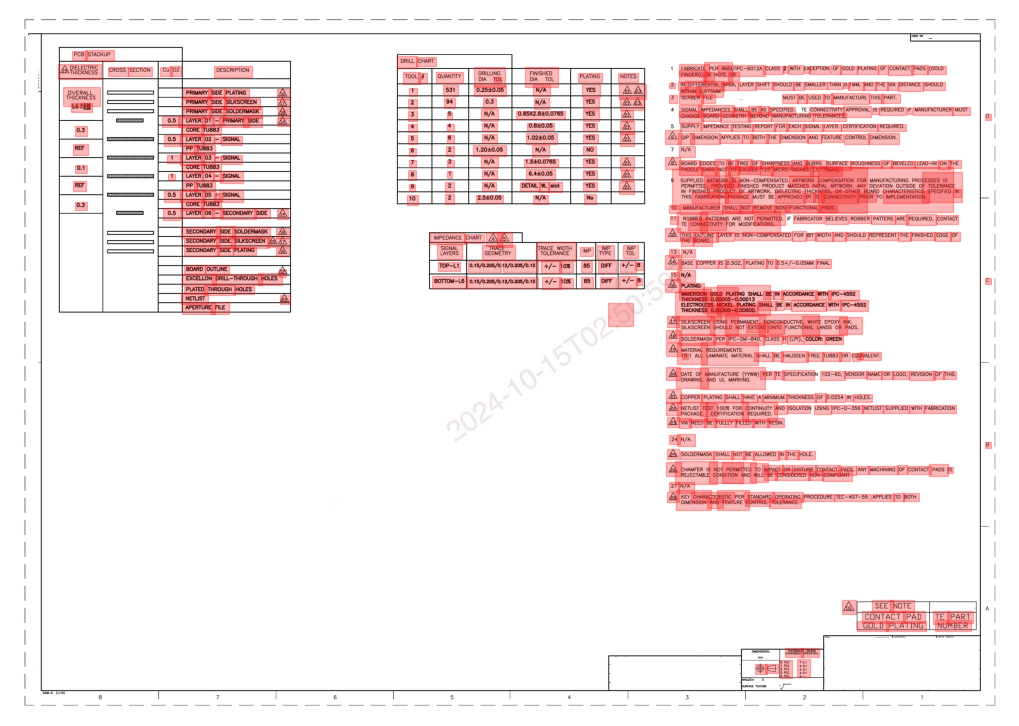

In [137]:
# Display the result (requires matplotlib & mplcursors to be installed)
result.show()

In [138]:
string_result = result.render()
print(string_result.replace("words:", "").replace("\n",""))

 PCB STACKUP CHART DRILL CROSS 2 SECTION EX Cu OZ CLASS WITH CEPTION OF GOLD PLATING OF DESCRIPTION PADS (GOLD CONTACT FABRICATE ANSI/PC-6012A AAPHICKRERS IN 16 PLATING NOTES # QUANTITY FINGERS) TOL TOOL RS DALNE ENSER 2 0. SHIFT SMALLER THAN IN AREA, LAYER SHOULD BE 1MM, AND THE VIA DIFFERENTIAL SHOULD DISTANCE 1 531 0.25:10.05 N/A SIDE WITHIN YES PRIMARY PLATING 0.075MM A6 AA 3 FILE FAVERAES MUST BE USED TO THIS PART. GERBER MANUFACTURE PRIMARY SIDE 94 SILKSCREEN 0.3 AA 2 N/A YES 1.6+816 AA IS SIDE IF AS SPECIFIED. CONNECTMTY PRIMARY REQUIRED SOLDERMASK MANUFACTURER IMPEDANCES 48 MUST SHALL BE SIGNAL APPROVAL 5 0.65X2.8:0.0765 3 N/A YES E BOARD BEYOND D MANUFACTURING TOLERANCES. GEOMETRY CHANGE - 01 A4 0.5 LAYER PRIMARY SIDE 0.80.05 4 N/A YES 4 SUPPLY IMPEDANCE TESTING REPORT FOR EACH SIGNAL LAYER. CERTIFICATION REQUIRED. TU883 0.3 A CORE - 02 6 N/A DIMENSION YES FEATURE 5 SIGNAL APPLIES TO 1.02:+0.05 BOTH THE AND 0.5 LAYER A QIP DIMENSION CONTROL DIMENSION. A PP TU883 REF NO 6 2 1.2

In [127]:
json_output

{'pages': [{'page_idx': 0,
   'dimensions': (2828, 3999),
   'orientation': {'value': None, 'confidence': None},
   'language': {'value': None, 'confidence': None},
   'blocks': [{'geometry': ((0.04296875, 0.03876897873939178),
      (0.9912109375, 0.9916115076909477)),
     'objectness_score': 0.7169049408357693,
     'lines': [{'geometry': ((0.060546875, 0.03876897873939178),
        (0.4248046875, 0.058102015558698705)),
       'objectness_score': 0.7445253431797028,
       'words': [{'value': 'L.',
         'confidence': 0.5351226329803467,
         'geometry': ((0.060546875, 0.042911772343529),
          (0.0703125, 0.05672108435731965)),
         'objectness_score': 0.6971883773803711,
         'crop_orientation': {'value': 0, 'confidence': None}},
        {'value': 'FABRICATE',
         'confidence': 0.9496960043907166,
         'geometry': ((0.0732421875, 0.03876897873939178),
          (0.1220703125, 0.058102015558698705)),
         'objectness_score': 0.7297559976577759,
    